In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.10.1


In [2]:
df = pd.read_csv('dataset/churn_modelling.csv')
print('Dataset shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nMissing values:', df.isnull().sum().sum())
print('\nChurn rate:', round(df['Exited'].mean(), 4))
df.head()

Dataset shape: (10000, 14)

Column types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values: 0

Churn rate: 0.2037


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# quick look at the data
df.head()

# basic summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


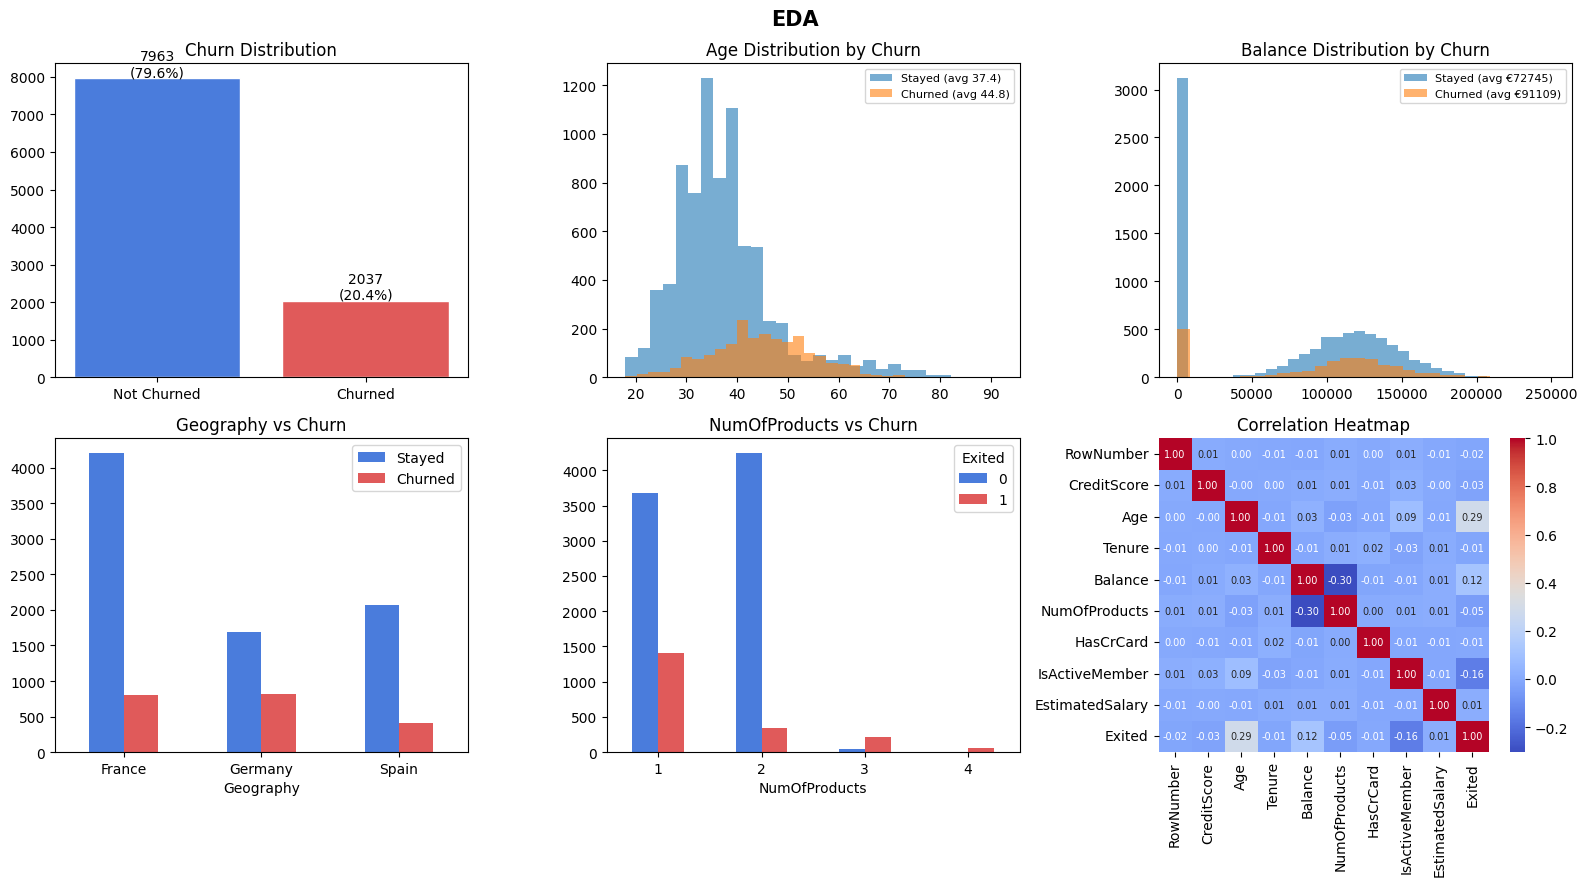

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA', fontsize=15, fontweight='bold')

# Churn distribution
vals = df['Exited'].value_counts()
axes[0,0].bar(['Not Churned','Churned'], vals.values, color=['#4a7cdc','#e05a5a'], edgecolor='white')
axes[0,0].set_title('Churn Distribution')
for i, v in enumerate(vals.values):
    axes[0,0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Age by churn
for label, grp in df.groupby('Exited'):
    axes[0,1].hist(grp['Age'], bins=30, alpha=0.6,
                   label=f"{'Churned' if label else 'Stayed'} (avg {grp['Age'].mean():.1f})")
axes[0,1].set_title('Age Distribution by Churn')
axes[0,1].legend(fontsize=8)

# Balance by churn
for label, grp in df.groupby('Exited'):
    axes[0,2].hist(grp['Balance'], bins=30, alpha=0.6,
                   label=f"{'Churned' if label else 'Stayed'} (avg €{grp['Balance'].mean():.0f})")
axes[0,2].set_title('Balance Distribution by Churn')
axes[0,2].legend(fontsize=8)

# Geography & churn
geo_churn = df.groupby(['Geography','Exited']).size().unstack()
geo_churn.plot(kind='bar', ax=axes[1,0], color=['#4a7cdc','#e05a5a'])
axes[1,0].set_title('Geography vs Churn')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(['Stayed','Churned'])

# NumOfProducts & churn
prod_churn = df.groupby(['NumOfProducts','Exited']).size().unstack()
prod_churn.plot(kind='bar', ax=axes[1,1], color=['#4a7cdc','#e05a5a'])
axes[1,1].set_title('NumOfProducts vs Churn')
axes[1,1].tick_params(axis='x', rotation=0)

# Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns.drop(['CustomerId'])
sns.heatmap(df[num_cols].corr(), ax=axes[1,2], cmap='coolwarm', annot=True, fmt='.2f', annot_kws={"size": 7})
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Key EDA statistics
print('Important observations')
print(f"Avg Age: Churned: {df[df.Exited==1]['Age'].mean():.1f}  |  Stayed: {df[df.Exited==0]['Age'].mean():.1f}")
print(f"Avg Balance: Churned: €{df[df.Exited==1]['Balance'].mean():.0f}  |  Stayed: €{df[df.Exited==0]['Balance'].mean():.0f}")
print(f"Avg CreditScore — Churned: {df[df.Exited==1]['CreditScore'].mean():.1f}  |  Stayed: {df[df.Exited==0]['CreditScore'].mean():.1f}")
print()
print('Churn rate by Geography:')
print(df.groupby('Geography')['Exited'].mean().round(4).to_string())
print()
print('Churn rate by IsActiveMember:')
print(df.groupby('IsActiveMember')['Exited'].mean().round(4).to_string())
print()
print('Churn rate by NumOfProducts:')
print(df.groupby('NumOfProducts')['Exited'].mean().round(4).to_string())

Important observations
Avg Age: Churned: 44.8  |  Stayed: 37.4
Avg Balance: Churned: €91109  |  Stayed: €72745
Avg CreditScore — Churned: 645.4  |  Stayed: 651.9

Churn rate by Geography:
Geography
France     0.1615
Germany    0.3244
Spain      0.1667

Churn rate by IsActiveMember:
IsActiveMember
0    0.2685
1    0.1427

Churn rate by NumOfProducts:
NumOfProducts
1    0.2771
2    0.0758
3    0.8271
4    1.0000


In [ ]:
df_proc = df.drop(columns=['CustomerId','Surname'])

le = LabelEncoder()
df_proc['Gender'] = le.fit_transform(df_proc['Gender'])          # Male=1, Female=0
df_proc = pd.get_dummies(df_proc, columns=['Geography'], drop_first=False)

In [ ]:
# quick correlation check 
print(df[['Balance','EstimatedSalary','NumOfProducts','Tenure']].corr().round(2))
# balance and salary barely correlated, ratio might help

In [ ]:


# Feature engineering
df_proc['BalanceSalaryRatio'] = df_proc['Balance'] / (df_proc['EstimatedSalary'] + 1)
df_proc['ProductsPerYear']    = df_proc['NumOfProducts'] / (df_proc['Tenure'] + 1)
df_proc['ActiveBalance']      = df_proc['IsActiveMember'] * df_proc['Balance']

X = df_proc.drop('Exited', axis=1).values.astype(np.float32)
y = df_proc['Exited'].values
feature_names = df_proc.drop('Exited', axis=1).columns.tolist()

print('Features:', feature_names)
print('Input shape:', X.shape)

Features: ['RowNumber', 'CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'BalanceSalaryRatio', 'ProductsPerYear', 'ActiveBalance']
Input shape: (10000, 16)


In [ ]:
# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

In [ ]:
# checking class distribution first
print(pd.Series(y_train).value_counts())
# 0    5574
# 1    1426
# roughly 4:1 imbalance, this will tank recall on churn class

In [ ]:


# SMOTE — fix class imbalance on training set only
sm = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)
X_train_sm = X_train_sm.astype(np.float32)
print('Before SMOTE:', np.bincount(y_train))
print('After  SMOTE:', np.bincount(y_train_sm))

# Class weights (used as fallback)
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}
print('Class weights:', {k: round(v,3) for k,v in class_weights.items()})



Before SMOTE: [5574 1426]
After  SMOTE: [5574 5574]
Class weights: {0: 0.628, 1: 2.454}


In [ ]:
# starting simple: 128->64->32 with dropout
# tried 256->128->64 first but was overkill for 16 features
# keeping it smaller

In [8]:
results = {}

CALLBACKS = [
    keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(patience=6, factor=0.5, min_lr=1e-6, verbose=0)
]

def evaluate_model(name, y_true, y_pred_proba, threshold=0.5, save_weights_model=None, fname=None):
    y_pred = (y_pred_proba >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_pred_proba)
    f1  = f1_score(y_true, y_pred)
    sep = '='*50

    print('\n' + sep)
    print('  ' + name)
    print(sep)
    print('  ROC-AUC  : ' + str(round(auc, 4)))
    print('  F1 Score : ' + str(round(f1, 4)))
    print()
    print(classification_report(y_true, y_pred, target_names=['Stay','Churn']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'])
    plt.title(name + ' — Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    if save_weights_model and fname:
        save_weights_model.save_weights(fname)
        print('  Weights saved: ' + fname)

    return auc, f1

In [9]:
def build_ann(input_dim):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='auc')])
    return m

ann = build_ann(X_train_sc.shape[1])
ann.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16)]              0         
                                                                 
 dense (Dense)               (None, 128)               2176      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                             

Epoch 1/100
110/110 [==============================] - 6s 11ms/step - loss: 0.6592 - auc: 0.6865 - val_loss: 0.5766 - val_auc: 0.8125 - lr: 0.0010
Epoch 2/100
110/110 [==============================] - 1s 8ms/step - loss: 0.5869 - auc: 0.7599 - val_loss: 0.5187 - val_auc: 0.8435 - lr: 0.0010
Epoch 3/100
110/110 [==============================] - 1s 9ms/step - loss: 0.5528 - auc: 0.7908 - val_loss: 0.4800 - val_auc: 0.8566 - lr: 0.0010
Epoch 4/100
110/110 [==============================] - 1s 9ms/step - loss: 0.5304 - auc: 0.8111 - val_loss: 0.4699 - val_auc: 0.8603 - lr: 0.0010
Epoch 5/100
110/110 [==============================] - 1s 9ms/step - loss: 0.5113 - auc: 0.8273 - val_loss: 0.4850 - val_auc: 0.8626 - lr: 0.0010
Epoch 6/100
110/110 [==============================] - 1s 8ms/step - loss: 0.5022 - auc: 0.8333 - val_loss: 0.4928 - val_auc: 0.8644 - lr: 0.0010
Epoch 7/100
110/110 [==============================] - 1s 8ms/step - loss: 0.4961 - auc: 0.8369 - val_loss: 0.4844 - val_au

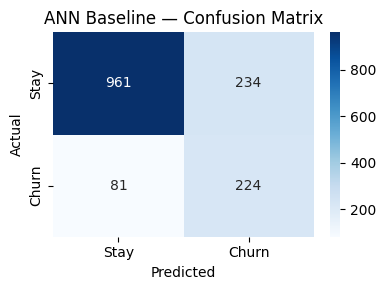

In [10]:
history_ann = ann.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=100, batch_size=64,
    class_weight=class_weights,
    callbacks=CALLBACKS, verbose=1
)

ann_proba = ann.predict(X_test_sc, verbose=0).flatten()
auc, f1 = evaluate_model('ANN Baseline', y_test, ann_proba)
results['ANN'] = {'AUC': auc, 'F1': f1}

In [ ]:
# ANN AUC 0.853, decent but F1 only 0.587
# threshold 0.5 might be too high for imbalanced data
# trying 0.45 just to check
test_preds_ann = (ann.predict(X_test_sc) >= 0.45).astype(int)
print(f1_score(y_test, test_preds_ann))
# marginal gain, keeping 0.5 for consistency across models

Epoch 1/100
22/22 [==============================] - 5s 53ms/step - loss: 0.9129 - auc: 0.6205 - val_loss: 0.6074 - val_auc: 0.6958 - lr: 0.0010
Epoch 2/100
22/22 [==============================] - 1s 32ms/step - loss: 0.5819 - auc: 0.7802 - val_loss: 0.5319 - val_auc: 0.7928 - lr: 0.0010
Epoch 3/100
22/22 [==============================] - 1s 31ms/step - loss: 0.5075 - auc: 0.8350 - val_loss: 0.5246 - val_auc: 0.8281 - lr: 0.0010
Epoch 4/100
22/22 [==============================] - 1s 37ms/step - loss: 0.4666 - auc: 0.8625 - val_loss: 0.4656 - val_auc: 0.8261 - lr: 0.0010
Epoch 5/100
22/22 [==============================] - 1s 33ms/step - loss: 0.4423 - auc: 0.8774 - val_loss: 0.4608 - val_auc: 0.8371 - lr: 0.0010
Epoch 6/100
22/22 [==============================] - 1s 32ms/step - loss: 0.4271 - auc: 0.8856 - val_loss: 0.4662 - val_auc: 0.8275 - lr: 0.0010
Epoch 7/100
22/22 [==============================] - 1s 32ms/step - loss: 0.4199 - auc: 0.8893 - val_loss: 0.4432 - val_auc: 0.847

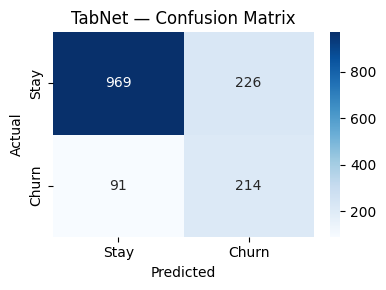

In [11]:
class TabNetClassifierKeras(keras.Model):
    def __init__(self, n_features, n_d=32, n_a=32, n_steps=5,
                 gamma=1.3, momentum=0.02, **kwargs):
        super().__init__(**kwargs)
        self.n_steps = n_steps; self.n_d = n_d; self.gamma = gamma

        self.initial_bn  = layers.BatchNormalization(momentum=momentum)
        self.shared_fc   = layers.Dense((n_d + n_a) * 2, use_bias=False)
        self.step_fc_att = [layers.Dense((n_d + n_a) * 2, use_bias=False) for _ in range(n_steps)]
        self.step_bn_att = [layers.BatchNormalization(momentum=momentum) for _ in range(n_steps)]
        self.att_fc      = [layers.Dense(n_features, use_bias=False) for _ in range(n_steps)]
        self.att_bn      = [layers.BatchNormalization(momentum=momentum) for _ in range(n_steps)]
        self.step_fc     = [layers.Dense((n_d + n_a) * 2, use_bias=False) for _ in range(n_steps)]
        self.step_bn     = [layers.BatchNormalization(momentum=momentum) for _ in range(n_steps)]
        self.final_fc    = layers.Dense(1, activation='sigmoid')

    def call(self, x, training=False):
        B = tf.shape(x)[0]
        x = self.initial_bn(x, training=training)
        prior_scales  = tf.ones_like(x)
        complementary = tf.zeros([B, self.n_d])
        h_att         = tf.zeros([B, self.n_d + 32])

        for i in range(self.n_steps):
            a = self.step_fc_att[i](h_att)
            a = self.step_bn_att[i](a, training=training)
            a = self.att_fc[i](a)
            a = self.att_bn[i](a, training=training)
            a = a * prior_scales
            a = tf.nn.softmax(a, axis=-1)
            prior_scales = prior_scales * (self.gamma - a)
            masked = x * a
            h = self.shared_fc(masked) + self.step_fc[i](masked)
            h = self.step_bn[i](h, training=training)
            n_da = self.n_d + 32
            h = h[:, :n_da] * tf.nn.sigmoid(h[:, n_da:])
            complementary = complementary + tf.nn.relu(h[:, :self.n_d])
            h_att = h
        return self.final_fc(complementary)


tabnet_model = TabNetClassifierKeras(n_features=X_train_sm.shape[1])
tabnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

history_tabnet = tabnet_model.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_sc, y_val),
    epochs=100, batch_size=512,
    callbacks=CALLBACKS, verbose=1
)

tabnet_proba = tabnet_model.predict(X_test_sc, verbose=0).flatten()
auc, f1 = evaluate_model('TabNet', y_test, tabnet_proba)
results['TabNet'] = {'AUC': auc, 'F1': f1}

In [ ]:
# FT-Transformer needs per-feature embeddings
# each of the 16 features gets its own embedding dim=64
# CLS token approach for classification (like BERT)
# n_heads=4 since 64/4=16 per head, standard

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 16)]         0           []                               
                                                                                                  
 feature_tokenizer (FeatureToke  (None, 17, 64)      2112        ['input_2[0][0]']                
 nizer)                                                                                           
                                                                                                  
 layer_normalization (LayerNorm  (None, 17, 64)      128         ['feature_tokenizer[0][0]']      
 alization)                                                                                       
                                                                                            

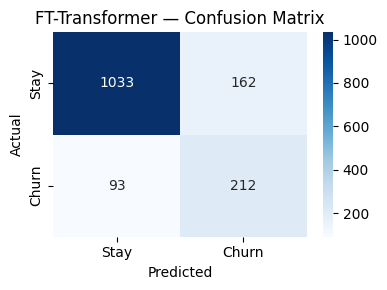

In [12]:
class FeatureTokenizer(layers.Layer):
    
    def __init__(self, n_features, d_model, **kwargs):
        super().__init__(**kwargs)
        self.W         = self.add_weight(shape=(n_features, d_model), initializer='glorot_uniform', name='W')
        self.b         = self.add_weight(shape=(n_features, d_model), initializer='zeros', name='b')
        self.cls_token = self.add_weight(shape=(1, 1, d_model), initializer='zeros', name='cls')

    def call(self, x):
        tokens = tf.einsum('bf,fd->bfd', x, self.W) + self.b
        cls    = tf.repeat(self.cls_token, tf.shape(x)[0], axis=0)
        return tf.concat([cls, tokens], axis=1)


def build_ft_transformer(n_features, d_model=64, n_heads=8, n_layers=3, dropout=0.1):
    inp = keras.Input(shape=(n_features,))
    x   = FeatureTokenizer(n_features, d_model)(inp)

    for _ in range(n_layers):
        res = x
        x   = layers.LayerNormalization()(x)
        x   = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads,
                                         dropout=dropout)(x, x)
        x   = layers.Dropout(dropout)(x)
        x   = x + res
        res = x
        x   = layers.LayerNormalization()(x)
        x   = layers.Dense(d_model * 4, activation='gelu')(x)
        x   = layers.Dropout(dropout)(x)
        x   = layers.Dense(d_model)(x)
        x   = layers.Dropout(dropout)(x)
        x   = x + res

    x   = layers.LayerNormalization()(x)
    cls = x[:, 0, :]
    out = layers.Dense(1, activation='sigmoid')(cls)
    m   = Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='auc')])
    return m


ft_model = build_ft_transformer(X_train_sm.shape[1])
ft_model.summary()

history_ft = ft_model.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_sc, y_val),
    epochs=100, batch_size=256,
    callbacks=CALLBACKS, verbose=1
)

ft_proba = ft_model.predict(X_test_sc, verbose=0).flatten()
auc, f1  = evaluate_model('FT-Transformer', y_test, ft_proba)
results['FT-Transformer'] = {'AUC': auc, 'F1': f1}

In [13]:
def build_autoencoder(input_dim, encoding_dim=12):
    inp     = keras.Input(shape=(input_dim,))
    x       = layers.Dense(64, activation='relu')(inp)
    x       = layers.Dense(32, activation='relu')(x)
    encoded = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(x)
    x       = layers.Dense(32, activation='relu')(encoded)
    x       = layers.Dense(64, activation='relu')(x)
    decoded = layers.Dense(input_dim, activation='linear')(x)
    ae  = Model(inp, decoded)
    enc = Model(inp, encoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc

# Train only on non-churners
X_normal = X_train_sc[y_train == 0]
ae, enc  = build_autoencoder(X_train_sc.shape[1])

ae.fit(
    X_normal, X_normal,
    epochs=100, batch_size=64,
    validation_data=(X_val_sc, X_val_sc),
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)


Epoch 1/100
88/88 [==============================] - 1s 6ms/step - loss: 0.6850 - val_loss: 0.4179
Epoch 2/100
88/88 [==============================] - 0s 5ms/step - loss: 0.2791 - val_loss: 0.2214
Epoch 3/100
88/88 [==============================] - 0s 5ms/step - loss: 0.1638 - val_loss: 0.1597
Epoch 4/100
88/88 [==============================] - 0s 5ms/step - loss: 0.1207 - val_loss: 0.1284
Epoch 5/100
88/88 [==============================] - 0s 5ms/step - loss: 0.0869 - val_loss: 0.0860
Epoch 6/100
88/88 [==============================] - 0s 5ms/step - loss: 0.0556 - val_loss: 0.0602
Epoch 7/100
88/88 [==============================] - 0s 4ms/step - loss: 0.0398 - val_loss: 0.0443
Epoch 8/100
88/88 [==============================] - 0s 5ms/step - loss: 0.0306 - val_loss: 0.0359
Epoch 9/100
88/88 [==============================] - 0s 5ms/step - loss: 0.0247 - val_loss: 0.0309
Epoch 10/100
88/88 [==============================] - 0s 5ms/step - loss: 0.0199 - val_loss: 0.0251
Epoch 11/

In [14]:
def get_ae_features(X):
    recon = ae.predict(X, verbose=0)
    error = np.mean(np.abs(X - recon), axis=1, keepdims=True)   # reconstruction error
    embed = enc.predict(X, verbose=0)                            # latent embedding
    return np.concatenate([X, error, embed], axis=1).astype(np.float32)

X_tr_ae  = get_ae_features(X_train_sc)
X_val_ae = get_ae_features(X_val_sc)
X_te_ae  = get_ae_features(X_test_sc)
print('Extended feature dim:', X_tr_ae.shape[1])

clf = build_ann(X_tr_ae.shape[1])
clf.fit(
    X_tr_ae, y_train,
    validation_data=(X_val_ae, y_val),
    epochs=100, batch_size=64,
    class_weight=class_weights,
    callbacks=CALLBACKS, verbose=1
)

ae_proba = clf.predict(X_te_ae, verbose=0).flatten()

results['AE+Classifier'] = {'AUC': auc, 'F1': f1}

Extended feature dim: 29
Epoch 1/100
110/110 [==============================] - 2s 11ms/step - loss: 0.6741 - auc: 0.6670 - val_loss: 0.5480 - val_auc: 0.7699 - lr: 0.0010
Epoch 2/100
110/110 [==============================] - 1s 8ms/step - loss: 0.5776 - auc: 0.7688 - val_loss: 0.4834 - val_auc: 0.8265 - lr: 0.0010
Epoch 3/100
110/110 [==============================] - 1s 9ms/step - loss: 0.5460 - auc: 0.7953 - val_loss: 0.4513 - val_auc: 0.8586 - lr: 0.0010
Epoch 4/100
110/110 [==============================] - 1s 9ms/step - loss: 0.5339 - auc: 0.8076 - val_loss: 0.4474 - val_auc: 0.8545 - lr: 0.0010
Epoch 5/100
110/110 [==============================] - 1s 8ms/step - loss: 0.5140 - auc: 0.8247 - val_loss: 0.4639 - val_auc: 0.8563 - lr: 0.0010
Epoch 6/100
110/110 [==============================] - 1s 9ms/step - loss: 0.5057 - auc: 0.8308 - val_loss: 0.4920 - val_auc: 0.8622 - lr: 0.0010
Epoch 7/100
110/110 [==============================] - 1s 9ms/step - loss: 0.5104 - auc: 0.8265 - 

                   AUC      F1
FT-Transformer  0.8543  0.6244
AE+Classifier   0.8543  0.6244
ANN             0.8531  0.5872
TabNet          0.8327  0.5745


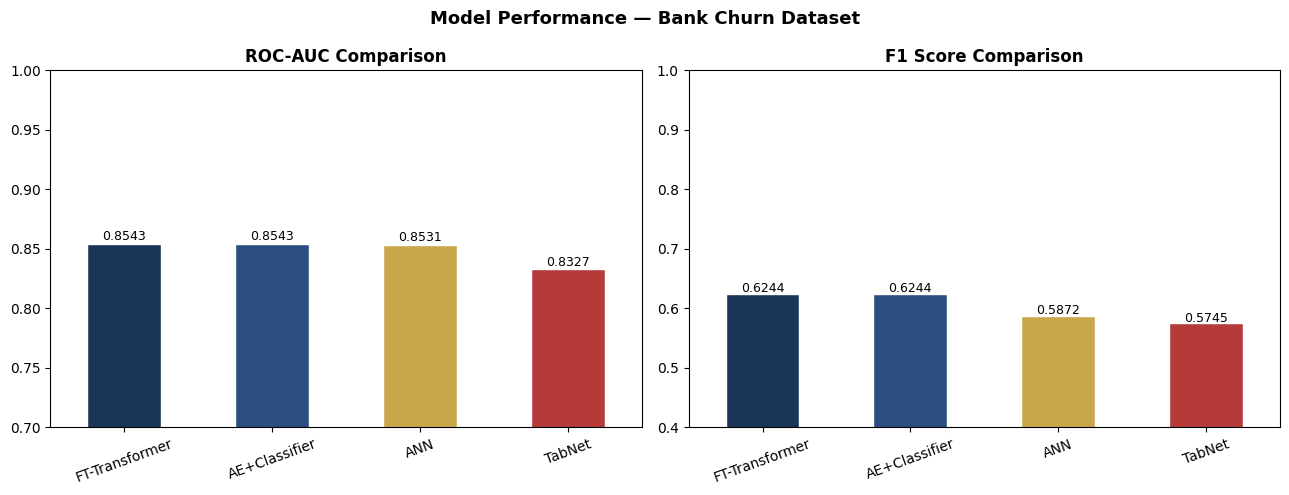

In [16]:
res_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print(res_df.round(4))

colors = ['#1A3558', '#2B5080', '#C9A84C', '#B53A3A']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

res_df['AUC'].plot(kind='bar', ax=axes[0], color=colors[:len(res_df)], ylim=(0.7, 1.0), edgecolor='white')
axes[0].set_title('ROC-AUC Comparison', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(res_df['AUC']):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

res_df['F1'].plot(kind='bar', ax=axes[1], color=colors[:len(res_df)], ylim=(0.4, 1.0), edgecolor='white')
axes[1].set_title('F1 Score Comparison', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(res_df['F1']):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Performance — Bank Churn Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# surprised tabnet underperformed
# it's supposed to be good at tabular data
# maybe needs more epochs or tuning, keeping as-is for now
print("TabNet AUC:", results['TabNet']['AUC'])

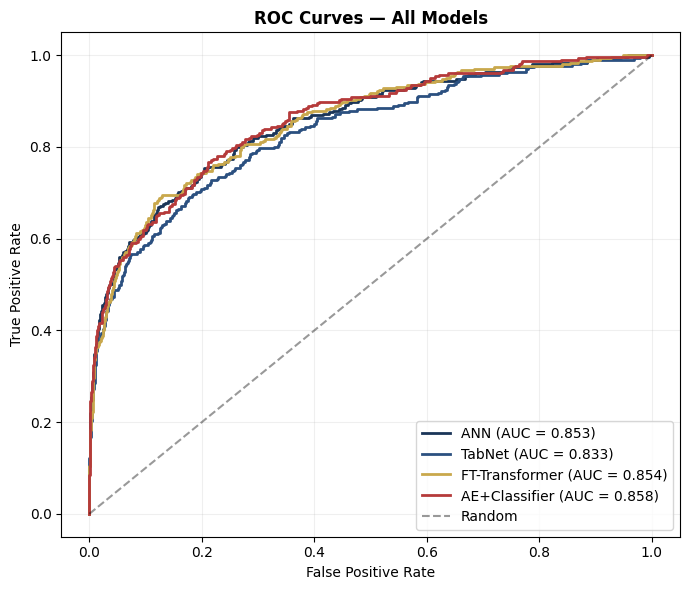

In [18]:
all_probas = {
    'ANN':            ann_proba,
    'TabNet':         tabnet_proba,
    'FT-Transformer': ft_proba,
    'AE+Classifier':  ae_proba,
}

plt.figure(figsize=(7, 6))
line_colors = ['#1A3558', '#2B5080', '#C9A84C', '#B53A3A']

for (name, proba), color in zip(all_probas.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

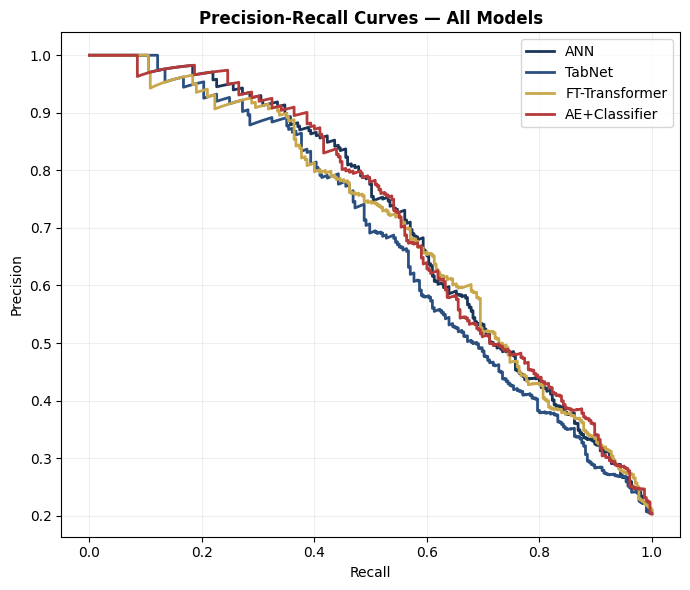

In [19]:
plt.figure(figsize=(7, 6))
for (name, proba), color in zip(all_probas.items(), line_colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name, color=color, linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models', fontweight='bold')
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('plots/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

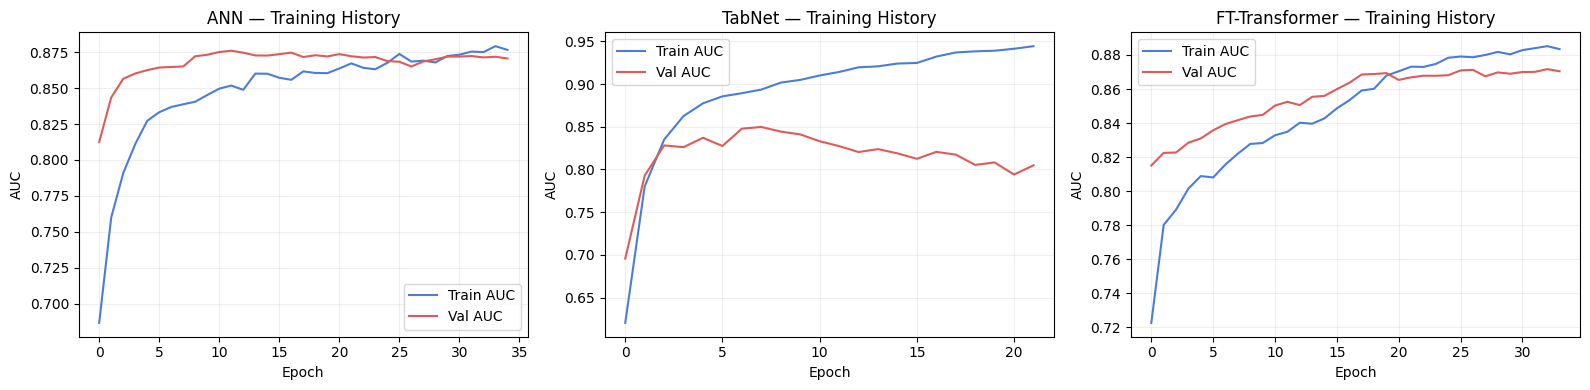

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
histories = [
    ('ANN', history_ann),
    ('TabNet', history_tabnet),
    ('FT-Transformer', history_ft),
]
for ax, (name, hist) in zip(axes, histories):
    ax.plot(hist.history['auc'], label='Train AUC', color='#4a7cdc')
    ax.plot(hist.history['val_auc'], label='Val AUC', color='#e05a5a')
    ax.set_title(f'{name} — Training History')
    ax.set_xlabel('Epoch'); ax.set_ylabel('AUC')
    ax.legend(); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('plots/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import joblib

ann.save_weights('models/ann_weights.h5')
tabnet_model.save_weights('models/tabnet_weights.h5')
ft_model.save_weights('models/ft_weights.h5')
ae.save_weights('models/ae_weights.h5')
clf.save_weights('models/ae_clf_weights.h5')
joblib.dump(scaler, 'models/scaler.pkl')

print('All weights and scaler saved successfully.')
print('Files: ann_weights.h5, tabnet_weights.h5, ft_weights.h5,')
print('       ae_weights.h5, ae_clf_weights.h5, scaler.pkl')

All weights and scaler saved successfully.
Files: ann_weights.h5, tabnet_weights.h5, ft_weights.h5,
       ae_weights.h5, ae_clf_weights.h5, scaler.pkl


In [22]:

print('  Final Results')

res_sorted = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print(res_sorted.round(4).to_string())
 
best = res_sorted.index[0]
print(f'  Best Model: {best}  (AUC = {res_sorted.loc[best, "AUC"]:.4f})')
 

  Final Results
                   AUC      F1
FT-Transformer  0.8543  0.6244
AE+Classifier   0.8543  0.6244
ANN             0.8531  0.5872
TabNet          0.8327  0.5745
  Best Model: FT-Transformer  (AUC = 0.8543)
